In [1]:
import pandas as pd

df = pd.read_csv("retail_sales_dataset.csv")
df.head()


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [2]:
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [3]:
df["Total Amount"].describe()

count    1000.000000
mean      456.000000
std       559.997632
min        25.000000
25%        60.000000
50%       135.000000
75%       900.000000
max      2000.000000
Name: Total Amount, dtype: float64

In [6]:
df["Total Amount"].mean()
df["Total Amount"].median()
df["Total Amount"].mode()[0]
df["Total Amount"].std()


559.997631555123

In [7]:
df["Date"] = pd.to_datetime(df["Date"])

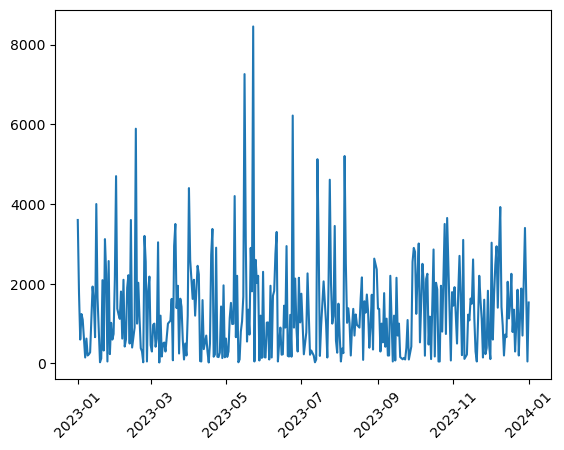

In [8]:
import matplotlib.pyplot as plt

sales = df.groupby("Date")["Total Amount"].sum()
plt.plot(sales)
plt.xticks(rotation=45)
plt.show()

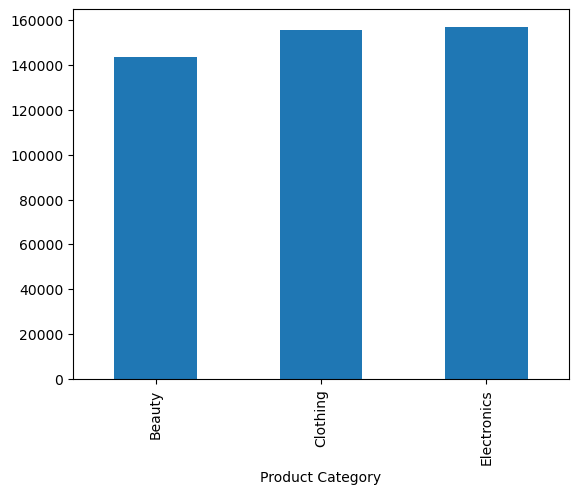

In [9]:
df.groupby("Product Category")["Total Amount"].sum().plot(kind="bar")
plt.show()

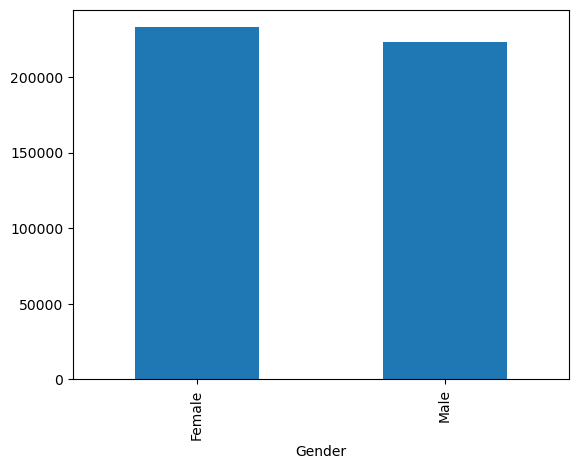

In [10]:
df.groupby("Gender")["Total Amount"].sum().plot(kind="bar")
plt.show()

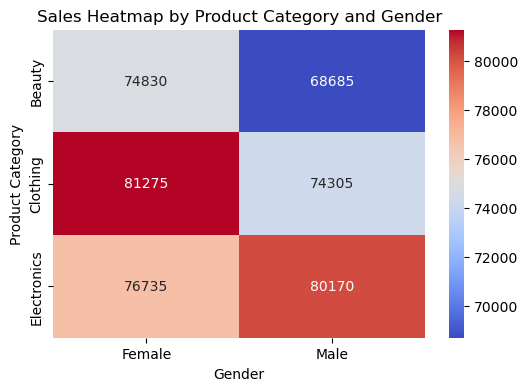

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = df.pivot_table(
    values="Total Amount",
    index="Product Category",
    columns="Gender",
    aggfunc="sum"
)

plt.figure(figsize=(6,4))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="coolwarm")
plt.title("Sales Heatmap by Product Category and Gender")
plt.show()
